# Task 3 : Customer Segmentation

## Step 1 : Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [8]:
df = pd.read_csv("Telco_Customer_Churn_Dataset .csv")

## Step 2 : Clean Dataset

In [4]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

df.dropna(inplace=True)

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Step 3 : Create Tenure Segment

In [11]:
tenure_bins = [0,12,24,48,72]

tenure_labels = [
    "0-12 Months",
    "13-24 Months",
    "25-48 Months",
    "49-72 Months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,25-48 Months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 Months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months


### Visualize Customer Distribution

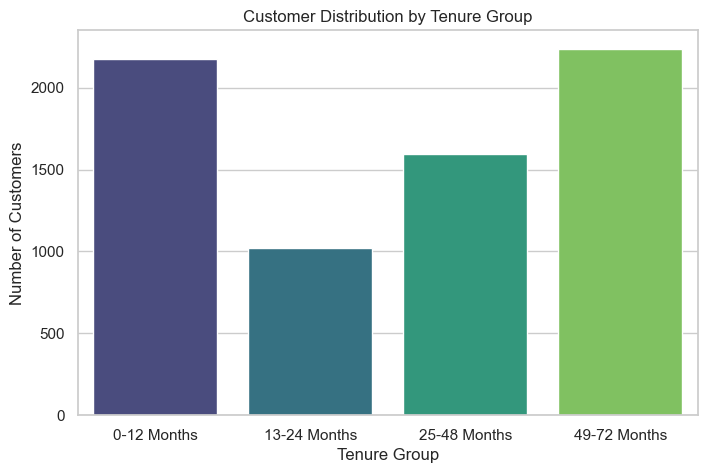

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="TenureGroup",
    hue='TenureGroup',
    data=df,
    palette="viridis",
    legend = False
)

plt.title("Customer Distribution by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.show()

### Churn Rate By Tenure

In [23]:
Tenure_Churn = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index',
)*100

Tenure_Churn.round(2)

Churn,No,Yes
TenureGroup,,
0-12 Months,52.32,47.68
13-24 Months,71.29,28.71
25-48 Months,79.61,20.39
49-72 Months,90.49,9.51


### Stacked Bar Chart

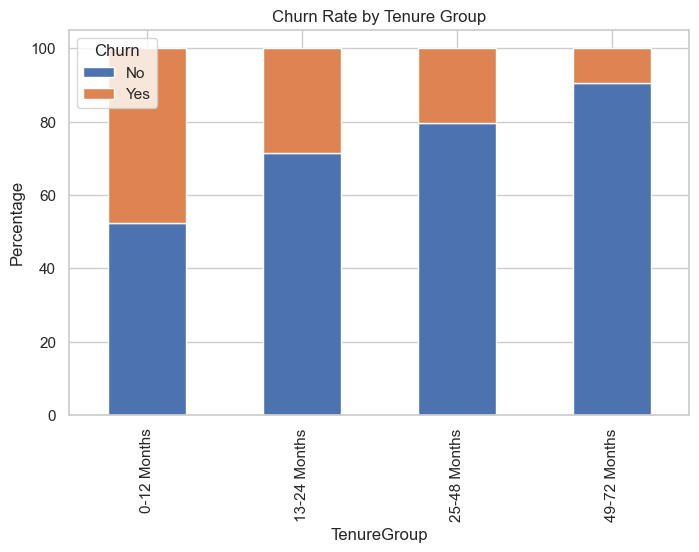

In [26]:
Tenure_Churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Rate by Tenure Group")
plt.ylabel("Percentage")

plt.show()

### Business Insight
##### Customers in their first year (0–12 months) have the highest churn rate. As tenure increases, churn decreases, indicating that customer loyalty strengthens over time.

## Step 4 : Monthly Charges Segmentation

In [28]:
charge_bins = [0,35,70,120]

charge_labels = [
    "Low",
    "Medium",
    "High"
]

df["ChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=charge_bins,
    labels=charge_labels
)

### Distribution

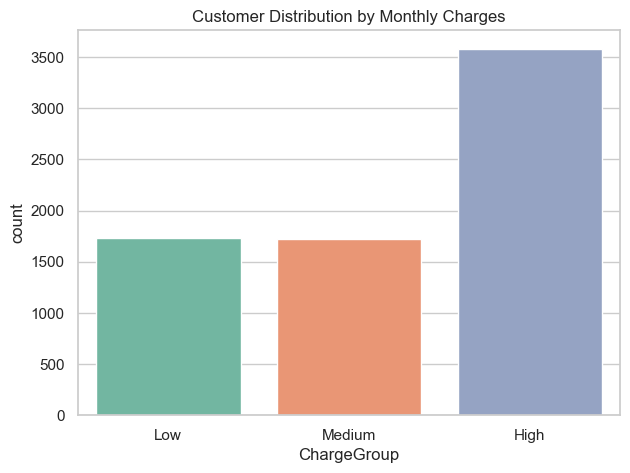

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="ChargeGroup",
    hue='ChargeGroup',
    data=df,
    palette="Set2"
)

plt.title("Customer Distribution by Monthly Charges")

plt.show()

### Churn Rate

In [31]:
charge_churn = pd.crosstab(
    df["ChargeGroup"],
    df["Churn"],
    normalize="index"
)*100

charge_churn.round(2)

Churn,No,Yes
ChargeGroup,,
Low,89.11,10.89
Medium,76.06,23.94
High,64.64,35.36


### Visualization

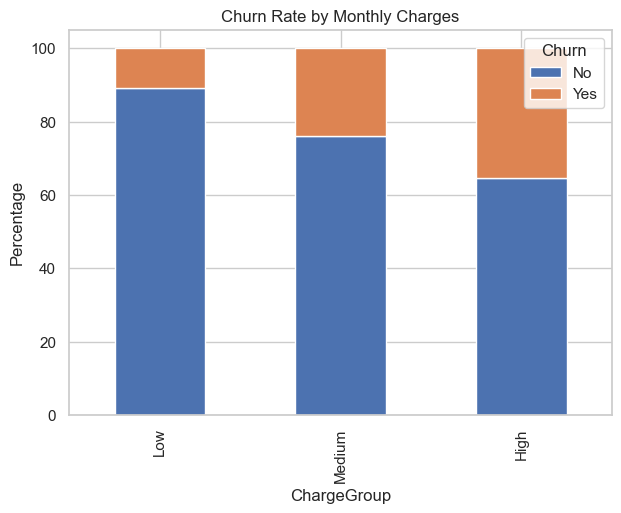

In [33]:
charge_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)

plt.title("Churn Rate by Monthly Charges")

plt.ylabel("Percentage")

plt.show()

### Business Insight

##### Customers paying higher monthly charges tend to churn more frequently, suggesting that pricing plays a role in customer retention.

## Step 5 : Contract Type Segmentation

In [34]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)*100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


### Visualization

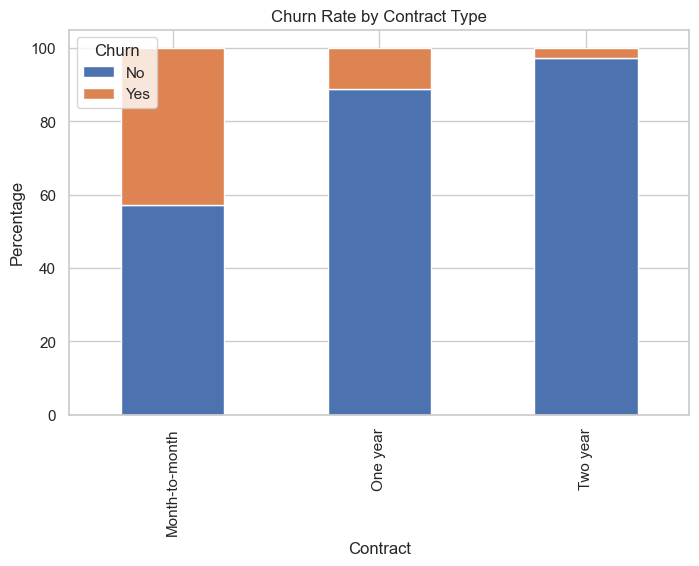

In [35]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")

plt.ylabel("Percentage")

plt.show()

### Business Insight

##### Month-to-month customers have the highest churn rate, whereas one-year and two-year contract customers are significantly more loyal.

## Step 6 : Combined Segmentation Analysis

In [37]:
segment_analysis = pd.crosstab(
    [df["TenureGroup"], df["Contract"]],
    df["Churn"],
    normalize="index"
)*100

segment_analysis.round(2)

Churn                            No    Yes
TenureGroup  Contract                     
0-12 Months  Month-to-month   48.65  51.35
             One year         89.43  10.57
             Two year        100.00   0.00
13-24 Months Month-to-month   62.28  37.72
             One year         91.88   8.12
             Two year        100.00   0.00
25-48 Months Month-to-month   67.08  32.92
             One year         89.38  10.62
             Two year         97.81   2.19
49-72 Months Month-to-month   73.98  26.02
             One year         87.07  12.93
             Two year         96.67   3.33

## Step 7 : Summary Table

In [41]:
summary = df.groupby("TenureGroup", observed=False).agg({
    "MonthlyCharges": "mean",
    "TotalCharges": "mean",
    "tenure": "mean"
}).round(2)

summary

,MonthlyCharges,TotalCharges,tenure
TenureGroup,,,
0-12 Months,56.17,276.62,4.76
13-24 Months,61.36,1126.26,18.35
25-48 Months,65.93,2390.45,36.19
49-72 Months,73.95,4685.51,63.05


## Step 8 : Customer Segmentation Insights

### Customer Segmentation Insights

- Customers with 0–12 months of tenure exhibit the highest churn rate.
- Customers paying higher monthly charges are more likely to leave.
- Month-to-month contract customers are the least loyal segment.
- Long-tenure customers on annual contracts represent the most stable customer group.
- New customers with high monthly charges and month-to-month contracts should be prioritized for retention campaigns.